# Hyperparameter Tuning - Two Modern Approaches

**Razorpay AI Buildathon 2026 - Track 02: AI Risk Manager**

Return-Risk Scorer for COD orders (Return-to-Origin prediction).

---

### The comparison

Two search strategies, run head to head on the finalists from `03`:

1. **Optuna** — `TPESampler(multivariate=True)` + `HyperbandPruner`
2. **FLAML** — cost-frugal `BlendSearch` (CFO + global search)

### What is held identical

| Held identical | Why it matters |
|---|---|
| Search space, parameter for parameter | Declared once in `src/tuning.py` and translated into each dialect. A space that differs is a comparison of spaces, not of searchers. |
| Objective | Mean PR-AUC over the same expanding-window folds of **train** |
| Seed | `20260101` for both |
| **Wall-clock budget** | Optuna is trial-native, FLAML is budget-native. A fixed trial count would flatter Optuna, which spends whatever a trial costs. A fixed *time* budget is the fair meeting point — and trials completed becomes a **result**, not a control. |

### What is not touched

Validation is scored **once per tuned configuration**, after each search closes. It is
never part of the objective. The test set is not opened in this notebook.

### The question actually being asked

Not "which library is better" in the abstract, but: **given 5 minutes of the same CPU
on the same problem, which strategy hands back the better configuration — and is the
difference bigger than the difference between tuned and untuned at all?**

That last part matters. If tuning buys 0.002 PR-AUC over the `03` defaults, the honest
report is that this problem is not tuning-limited.

## 1. Load finalists & search space definition

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluate import classification_metrics
from src.features import TARGET
from src.models import SEED, build_pipeline, model_input_columns, model_zoo
from src.tuning import (
    apply_params,
    cheap_corner,
    optuna_history,
    run_flaml,
    run_optuna,
    space_for,
    space_summary,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

FIG = ROOT / "reports/figures"
RES = ROOT / "reports/results"
MODELS = ROOT / "models"
MODELS.mkdir(exist_ok=True)

# The budget both strategies get, per finalist. Identical for both.
TIME_BUDGET_S = 300
N_TUNE_FOLDS = 3

In [2]:
def load_split(name: str) -> pd.DataFrame:
    if name == "test":
        raise PermissionError(
            "04_hyperparameter_tuning may not read the test split. It is opened "
            "once, in 05_final_evaluation.ipynb, after the final model is selected."
        )
    return pd.read_parquet(ROOT / f"data/processed/{name}.parquet")


train = load_split("train")
val = load_split("val")
COLS = model_input_columns()
y_train = train[TARGET].to_numpy()
y_val = val[TARGET].to_numpy()

# Finalists come from 03's persisted output, not from a hardcoded list, so this
# notebook cannot silently disagree with the benchmark that chose them.
bench = json.load(open(RES / "03_benchmark_summary.json", encoding="utf-8"))
FINALISTS = bench["finalists"]
baseline = {r["key"]: r for r in bench["leaderboard"]}
CEILING = bench["bayes_ceiling_val"]

zoo = model_zoo(seed=SEED)
print("Finalists carried forward from 03:\n")
for k in FINALISTS:
    r = baseline[k]
    print(f"  {zoo[k].label:<24} untuned val PR-AUC {r['val_pr_auc']:.4f}   "
          f"CV {r['cv_pr_auc_mean']:.4f}")
print(f"\nBayes ceiling (val): PR-AUC {CEILING['pr_auc']:.4f}")
print(f"budget per (model, strategy): {TIME_BUDGET_S}s   |   objective folds: {N_TUNE_FOLDS}")

Finalists carried forward from 03:

  Logistic Regression      untuned val PR-AUC 0.3939   CV 0.4145
  Extra Trees              untuned val PR-AUC 0.4013   CV 0.4061
  CatBoost                 untuned val PR-AUC 0.3931   CV 0.4012

Bayes ceiling (val): PR-AUC 0.5548
budget per (model, strategy): 300s   |   objective folds: 3


In [3]:
# The space, shown once. Both libraries receive exactly this.
for k in FINALISTS:
    print(f"=== {zoo[k].label} ===")
    display(space_summary(k).style.hide(axis="index"))
    print(f"FLAML low-cost starting corner: {cheap_corner(k)}")
    print()

=== Logistic Regression ===


parameter,type,low,high,scale,choices
C,float,0.001000,100.000000,log,
class_weight,cat,nan,nan,-,"(None,)"


FLAML low-cost starting corner: {'C': 1.0}

=== Extra Trees ===


parameter,type,low,high,scale,choices
n_estimators,int,100.000000,800.000000,linear,
max_depth,int,3.000000,30.000000,linear,
min_samples_leaf,int,1.000000,100.000000,log,
max_features,float,0.100000,1.000000,linear,


FLAML low-cost starting corner: {'n_estimators': 100, 'max_depth': 6}

=== CatBoost ===


parameter,type,low,high,scale,choices
iterations,int,100.000000,900.000000,linear,
learning_rate,float,0.010000,0.300000,log,
depth,int,3.000000,10.000000,linear,
l2_leaf_reg,float,0.500000,50.000000,log,
random_strength,float,0.001000,10.000000,log,
bagging_temperature,float,0.000000,2.000000,linear,


FLAML low-cost starting corner: {'iterations': 100, 'depth': 3}



## 2. APPROACH 1 - Optuna: multivariate TPE + HyperbandPruner

In [4]:
print("""Optuna configuration:

  sampler  TPESampler(multivariate=True, seed=SEED)
           multivariate models the JOINT distribution over parameters rather
           than each independently. For boosters that matters: learning rate and
           tree count trade off against each other, and an independent sampler
           cannot see that ridge.

  pruner   HyperbandPruner(min_resource=1, max_resource=3, reduction_factor=3)
           the objective reports an intermediate score after every CV fold, so a
           configuration that is clearly poor on fold 0 is stopped before it
           spends budget on folds 1 and 2. That is how Optuna gets more trials
           out of the same wall clock.
""")

OPTUNA_STUDIES, OPTUNA_HIST = {}, {}
for k in FINALISTS:
    t0 = time.time()
    study = run_optuna(zoo[k], train, y_train, COLS,
                       time_budget_s=TIME_BUDGET_S, n_splits=N_TUNE_FOLDS, seed=SEED)
    hist = optuna_history(study)
    OPTUNA_STUDIES[k], OPTUNA_HIST[k] = study, hist

    done = (hist.state == "COMPLETE").sum()
    pruned = (hist.state == "PRUNED").sum()
    print(f"{zoo[k].label:<24} best CV PR-AUC {study.best_value:.4f}   "
          f"{done} complete + {pruned} pruned in {time.time() - t0:.0f}s")

Optuna configuration:

  sampler  TPESampler(multivariate=True, seed=SEED)
           multivariate models the JOINT distribution over parameters rather
           than each independently. For boosters that matters: learning rate and
           tree count trade off against each other, and an independent sampler
           cannot see that ridge.

  pruner   HyperbandPruner(min_resource=1, max_resource=3, reduction_factor=3)
           the objective reports an intermediate score after every CV fold, so a
           configuration that is clearly poor on fold 0 is stopped before it
           spends budget on folds 1 and 2. That is how Optuna gets more trials
           out of the same wall clock.



D:\M.TECH\SEM-3\Razor pay\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\M.TECH\SEM-3\Razor pay\.venv\Lib\site-packages\optuna\_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(


Logistic Regression      best CV PR-AUC 0.4294   255 complete + 168 pruned in 307s


D:\M.TECH\SEM-3\Razor pay\.venv\Lib\site-packages\optuna\_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(


Extra Trees              best CV PR-AUC 0.4181   26 complete + 17 pruned in 300s


D:\M.TECH\SEM-3\Razor pay\.venv\Lib\site-packages\optuna\_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(


CatBoost                 best CV PR-AUC 0.4227   13 complete + 3 pruned in 304s


## 3. Optuna study analysis (importance, parallel coordinate, slice)

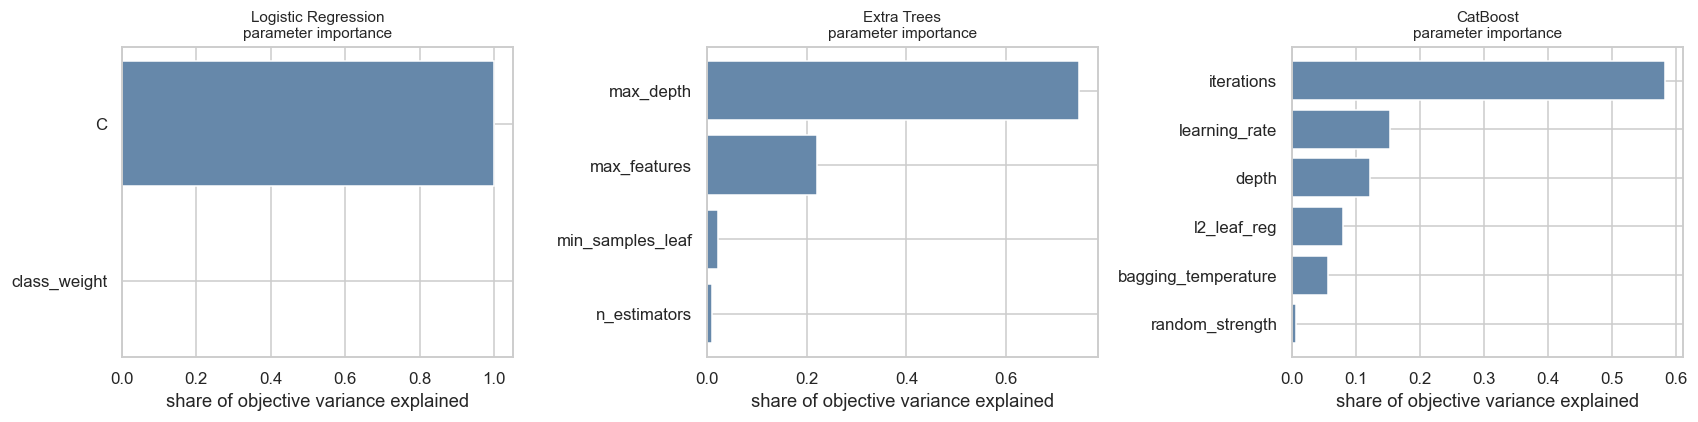

model,CatBoost,Extra Trees,Logistic Regression
parameter,,,
C,NaN,NaN,1.0
bagging_temperature,0.057,NaN,NaN
class_weight,NaN,NaN,0.0
depth,0.121,NaN,NaN
iterations,0.582,NaN,NaN
l2_leaf_reg,0.080,NaN,NaN
learning_rate,0.153,NaN,NaN
max_depth,NaN,0.747,NaN
max_features,NaN,0.221,NaN


In [5]:
import optuna

imp_rows = []
for k in FINALISTS:
    try:
        imp = optuna.importance.get_param_importances(OPTUNA_STUDIES[k])
    except Exception as exc:
        print(f"{zoo[k].label}: importance unavailable ({exc})")
        continue
    for p, v in imp.items():
        imp_rows.append({"model": zoo[k].label, "parameter": p, "importance": v})

importance = pd.DataFrame(imp_rows)
if len(importance):
    fig, axes = plt.subplots(1, len(FINALISTS), figsize=(5.2 * len(FINALISTS), 4))
    axes = np.atleast_1d(axes)
    for ax, k in zip(axes, FINALISTS):
        sub = (importance[importance.model == zoo[k].label]
               .sort_values("importance"))
        ax.barh(sub.parameter, sub.importance, color="#68a")
        ax.set_title(f"{zoo[k].label}\nparameter importance", fontsize=10)
        ax.set_xlabel("share of objective variance explained")
    plt.tight_layout()
    plt.savefig(FIG / "04_optuna_param_importance.png", bbox_inches="tight")
    plt.show()
    display(importance.pivot(index="parameter", columns="model",
                             values="importance").round(3))

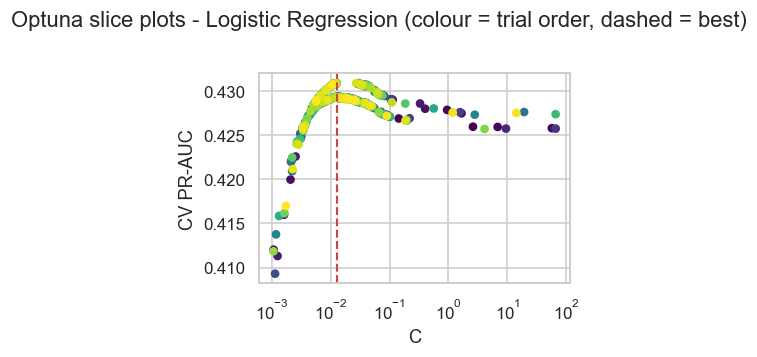

In [6]:
# Slice plots: what the sampler learned about each parameter, one at a time.
lead = FINALISTS[0]
study = OPTUNA_STUDIES[lead]
params = [p.name for p in space_for(lead) if p.kind != "cat"]
params = [p for p in params if p in study.best_params]

ncol = min(4, len(params))
nrow = int(np.ceil(len(params) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow), squeeze=False)
completed = [t for t in study.trials if t.value is not None]
for ax, p in zip(axes.ravel(), params):
    xs = [t.params[p] for t in completed if p in t.params]
    ys = [t.value for t in completed if p in t.params]
    ax.scatter(xs, ys, s=22, c=range(len(xs)), cmap="viridis")
    ax.axvline(study.best_params[p], ls="--", c="#c44", lw=1.4)
    ax.set_xlabel(p)
    ax.set_ylabel("CV PR-AUC")
    spec = next(s for s in space_for(lead) if s.name == p)
    if spec.log:
        ax.set_xscale("log")
for ax in axes.ravel()[len(params):]:
    ax.axis("off")
fig.suptitle(f"Optuna slice plots - {zoo[lead].label} "
             "(colour = trial order, dashed = best)", y=1.01)
plt.tight_layout()
plt.savefig(FIG / "04_optuna_slice.png", bbox_inches="tight")
plt.show()

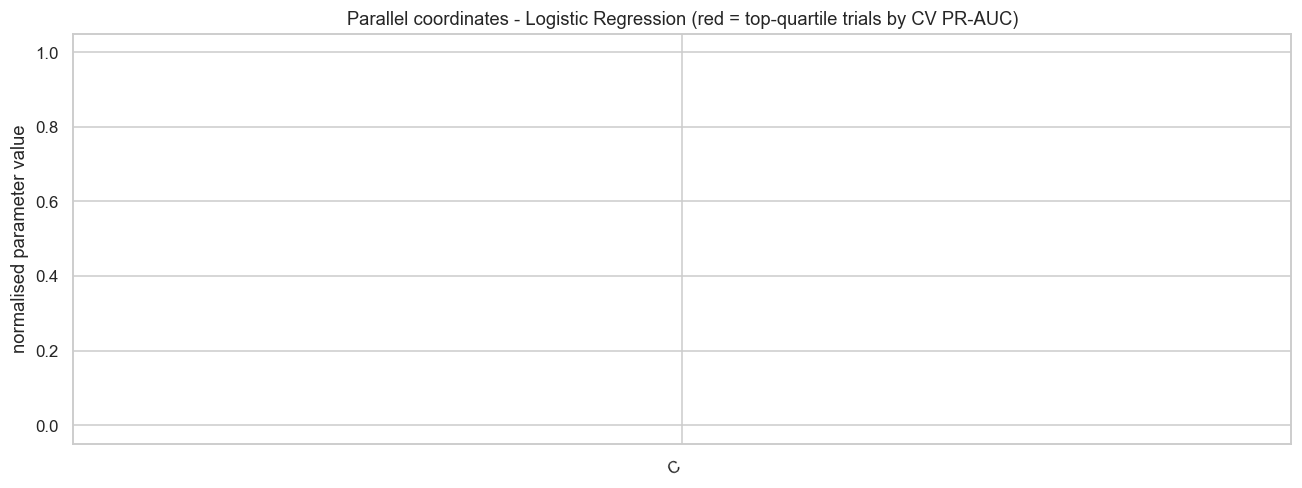

In [7]:
# Parallel coordinates over the top quartile of trials: where the good region is.
fig, ax = plt.subplots(figsize=(12, 4.6))
comp = pd.DataFrame([
    {**t.params, "value": t.value}
    for t in OPTUNA_STUDIES[lead].trials if t.value is not None
])
numeric = [c for c in comp.columns
           if c != "value" and pd.api.types.is_numeric_dtype(comp[c])]
norm = comp[numeric].apply(
    lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0)
cut = comp.value.quantile(0.75)
for i, row in norm.iterrows():
    good = comp.value.iat[i] >= cut
    ax.plot(range(len(numeric)), row.values,
            color="#c44" if good else "#ccc",
            alpha=0.85 if good else 0.35, lw=1.6 if good else 0.8, zorder=3 if good else 1)
ax.set_xticks(range(len(numeric)), numeric, rotation=25, ha="right")
ax.set_ylabel("normalised parameter value")
ax.set_title(f"Parallel coordinates - {zoo[lead].label} "
             "(red = top-quartile trials by CV PR-AUC)")
plt.tight_layout()
plt.savefig(FIG / "04_optuna_parallel_coords.png", bbox_inches="tight")
plt.show()

## 4. APPROACH 2 - FLAML: cost-frugal BlendSearch/CFO

In [8]:
print("""FLAML configuration:

  searcher  BlendSearch(seed=SEED, low_cost_partial_config=<cheap corner>)
            BlendSearch runs CFO (a local, cost-aware search) alongside a global
            search and blends them.

  The premise: evaluation cost varies enormously across the space. 900 trees cost
  roughly nine times what 100 do, so a searcher that ignores cost spends most of
  its budget in the expensive corner. BlendSearch starts from a CHEAP
  configuration and expands outward, buying many cheap trials instead of a few
  expensive ones.

  low_cost_partial_config is where that prior is declared. Leaving it empty would
  throw away the entire point of the method, so it is specified per model in
  src/tuning.py::cheap_corner and printed above -- visible and arguable rather
  than hidden.

  Same space. Same seed. Same objective. Same {}s.
""".format(TIME_BUDGET_S))

FLAML_HIST, FLAML_BEST = {}, {}
for k in FINALISTS:
    t0 = time.time()
    analysis, hist = run_flaml(zoo[k], train, y_train, COLS,
                               time_budget_s=TIME_BUDGET_S, n_splits=N_TUNE_FOLDS,
                               seed=SEED, low_cost_hint=cheap_corner(k))
    FLAML_HIST[k] = hist
    best_row = hist.loc[hist.value.idxmax()]
    FLAML_BEST[k] = {"value": float(best_row.value), "config": best_row.config}
    print(f"{zoo[k].label:<24} best CV PR-AUC {best_row.value:.4f}   "
          f"{len(hist)} trials in {time.time() - t0:.0f}s")

FLAML configuration:

  searcher  BlendSearch(seed=SEED, low_cost_partial_config=<cheap corner>)
            BlendSearch runs CFO (a local, cost-aware search) alongside a global
            search and blends them.

  The premise: evaluation cost varies enormously across the space. 900 trees cost
  roughly nine times what 100 do, so a searcher that ignores cost spends most of
  its budget in the expensive corner. BlendSearch starts from a CHEAP
  configuration and expands outward, buying many cheap trials instead of a few
  expensive ones.

  low_cost_partial_config is where that prior is declared. Leaving it empty would
  throw away the entire point of the method, so it is specified per model in
  src/tuning.py::cheap_corner and printed above -- visible and arguable rather
  than hidden.

  Same space. Same seed. Same objective. Same 300s.



You passed a `space` parameter to OptunaSearch that contained unresolved search space definitions. OptunaSearch should however be instantiated with fully configured search spaces only. To use Ray Tune's automatic search space conversion, pass the space definition as part of the `config` argument to `tune.run()` instead.


You passed a `space` parameter to OptunaSearch that contained unresolved search space definitions. OptunaSearch should however be instantiated with fully configured search spaces only. To use Ray Tune's automatic search space conversion, pass the space definition as part of the `config` argument to `tune.run()` instead.


Logistic Regression      best CV PR-AUC 0.4293   378 trials in 301s


You passed a `space` parameter to OptunaSearch that contained unresolved search space definitions. OptunaSearch should however be instantiated with fully configured search spaces only. To use Ray Tune's automatic search space conversion, pass the space definition as part of the `config` argument to `tune.run()` instead.


Extra Trees              best CV PR-AUC 0.4089   67 trials in 303s


CatBoost                 best CV PR-AUC 0.4243   38 trials in 305s


## 5. Head-to-head: same budget, same space, same seed

In [9]:
rows = []
for k in FINALISTS:
    oh, fh = OPTUNA_HIST[k], FLAML_HIST[k]
    o_best = OPTUNA_STUDIES[k].best_value
    f_best = FLAML_BEST[k]["value"]
    rows.append({
        "model": zoo[k].label,
        "optuna_best_cv": o_best,
        "flaml_best_cv": f_best,
        "delta_optuna_minus_flaml": o_best - f_best,
        "optuna_trials": int((oh.state == "COMPLETE").sum()),
        "optuna_pruned": int((oh.state == "PRUNED").sum()),
        "flaml_trials": len(fh),
        "untuned_cv": baseline[k]["cv_pr_auc_mean"],
    })
h2h = pd.DataFrame(rows)
h2h["winner"] = np.where(h2h.delta_optuna_minus_flaml > 0, "Optuna", "FLAML")
h2h["tuning_gain_vs_untuned"] = (
    h2h[["optuna_best_cv", "flaml_best_cv"]].max(axis=1) - h2h.untuned_cv)
display(h2h.round(4).style.hide(axis="index"))

model,optuna_best_cv,flaml_best_cv,delta_optuna_minus_flaml,optuna_trials,optuna_pruned,flaml_trials,untuned_cv,winner,tuning_gain_vs_untuned
Logistic Regression,0.429400,0.429300,0.000000,255,168,378,0.414500,Optuna,0.014900
Extra Trees,0.418100,0.408900,0.009200,26,17,67,0.406100,Optuna,0.012100
CatBoost,0.422700,0.424300,-0.001600,13,3,38,0.401200,FLAML,0.023100


In [10]:
print(f"""Read the trial counts before the scores.

Both strategies had exactly {TIME_BUDGET_S} seconds. The number of configurations each
got through is a RESULT of its cost model, not a setting we chose:

""")
for _, r in h2h.iterrows():
    tot_o = r.optuna_trials + r.optuna_pruned
    print(f"  {r.model:<24} Optuna {tot_o:>3} trials "
          f"({r.optuna_pruned} pruned early)   FLAML {r.flaml_trials:>3} trials")
print(f"""
Optuna's Hyperband pruner and FLAML's cost-frugal search are two different
answers to the same problem -- that a fixed budget buys either a few careful
evaluations or many cheap ones. Neither is universally right; this table is what
happened on THIS problem at THIS budget.""")

Read the trial counts before the scores.

Both strategies had exactly 300 seconds. The number of configurations each
got through is a RESULT of its cost model, not a setting we chose:


  Logistic Regression      Optuna 423 trials (168 pruned early)   FLAML 378 trials
  Extra Trees              Optuna  43 trials (17 pruned early)   FLAML  67 trials
  CatBoost                 Optuna  16 trials (3 pruned early)   FLAML  38 trials

Optuna's Hyperband pruner and FLAML's cost-frugal search are two different
answers to the same problem -- that a fixed budget buys either a few careful
evaluations or many cheap ones. Neither is universally right; this table is what
happened on THIS problem at THIS budget.


## 6. Convergence comparison

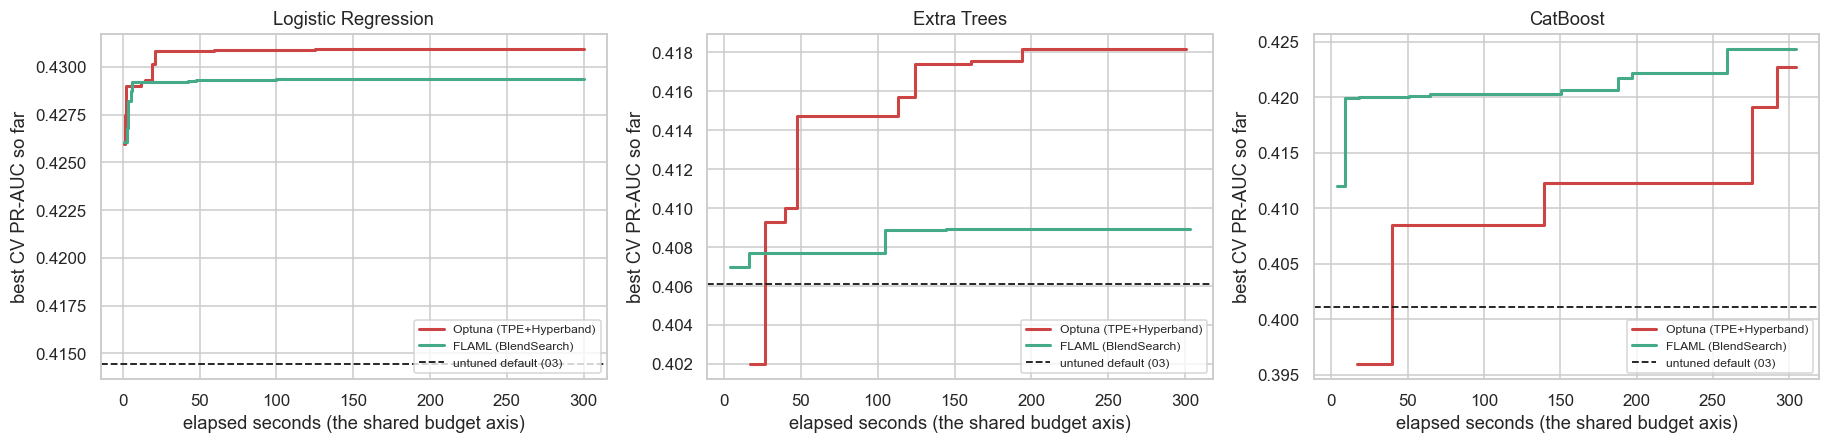

Time is the honest x-axis here, not trial number. Plotting against trial
index would show FLAML "converging slower" purely because it takes more, cheaper
steps -- which is the strategy working as designed, not failing.


In [11]:
fig, axes = plt.subplots(1, len(FINALISTS), figsize=(5.6 * len(FINALISTS), 4.2),
                         squeeze=False)
for ax, k in zip(axes[0], FINALISTS):
    oh = OPTUNA_HIST[k].dropna(subset=["elapsed_s"])
    fh = FLAML_HIST[k]
    ax.step(oh.elapsed_s, oh.running_best, where="post", lw=2,
            label=f"Optuna (TPE+Hyperband)", color="#c44")
    ax.step(fh.elapsed_s, fh.running_best, where="post", lw=2,
            label="FLAML (BlendSearch)", color="#4a8")
    ax.axhline(baseline[k]["cv_pr_auc_mean"], ls="--", c="k", lw=1.2,
               label="untuned default (03)")
    ax.set_xlabel("elapsed seconds (the shared budget axis)")
    ax.set_ylabel("best CV PR-AUC so far")
    ax.set_title(zoo[k].label)
    ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(FIG / "04_convergence.png", bbox_inches="tight")
plt.show()

print("""Time is the honest x-axis here, not trial number. Plotting against trial
index would show FLAML "converging slower" purely because it takes more, cheaper
steps -- which is the strategy working as designed, not failing.""")

In [12]:
# How fast did each strategy reach within 0.001 PR-AUC of its own final answer?
speed = []
for k in FINALISTS:
    for name, hist, best in [
        ("Optuna", OPTUNA_HIST[k].dropna(subset=["elapsed_s"]), OPTUNA_STUDIES[k].best_value),
        ("FLAML", FLAML_HIST[k], FLAML_BEST[k]["value"]),
    ]:
        reached = hist[hist.running_best >= best - 0.001]
        speed.append({
            "model": zoo[k].label, "strategy": name,
            "final_cv_pr_auc": best,
            "seconds_to_within_0.001": (reached.elapsed_s.iloc[0]
                                        if len(reached) else np.nan),
            "trials_to_get_there": (int(reached.trial.iloc[0]) + 1
                                    if len(reached) else np.nan),
        })
display(pd.DataFrame(speed).round(4).style.hide(axis="index"))

model,strategy,final_cv_pr_auc,seconds_to_within_0.001,trials_to_get_there
Logistic Regression,Optuna,0.429400,2.306500,3
Logistic Regression,FLAML,0.429300,5.282200,6
Extra Trees,Optuna,0.418100,123.958800,13
Extra Trees,FLAML,0.408900,105.071900,21
CatBoost,Optuna,0.422700,291.715000,14
CatBoost,FLAML,0.424300,259.399200,34


## 7. Best configuration per approach

In [13]:
configs = []
for k in FINALISTS:
    configs.append({"model": zoo[k].label, "strategy": "Optuna",
                    "cv_pr_auc": OPTUNA_STUDIES[k].best_value,
                    "config": OPTUNA_STUDIES[k].best_params})
    configs.append({"model": zoo[k].label, "strategy": "FLAML",
                    "cv_pr_auc": FLAML_BEST[k]["value"],
                    "config": FLAML_BEST[k]["config"]})

for c in configs:
    print(f"{c['model']} / {c['strategy']}  ->  CV PR-AUC {c['cv_pr_auc']:.4f}")
    for p, v in sorted(c["config"].items()):
        print(f"    {p:<22} {v}")
    print()

Logistic Regression / Optuna  ->  CV PR-AUC 0.4294
    C                      0.0128464370286847
    class_weight           None

Logistic Regression / FLAML  ->  CV PR-AUC 0.4293
    C                      0.014242495933001708
    class_weight           None

Extra Trees / Optuna  ->  CV PR-AUC 0.4181
    max_depth              6
    max_features           0.21576353559036648
    min_samples_leaf       1
    n_estimators           333

Extra Trees / FLAML  ->  CV PR-AUC 0.4089
    max_depth              5
    max_features           0.7957580606817404
    min_samples_leaf       2
    n_estimators           126

CatBoost / Optuna  ->  CV PR-AUC 0.4227
    bagging_temperature    0.298463016710414
    depth                  3
    iterations             225
    l2_leaf_reg            9.165899293428534
    learning_rate          0.03727128176502571
    random_strength        0.43385201922201505

CatBoost / FLAML  ->  CV PR-AUC 0.4243
    bagging_temperature    1.1544506140027266
    depth  

In [14]:
# Did the two strategies land in the same region, or find different optima?
lead_cfgs = {c["strategy"]: c["config"] for c in configs if c["model"] == zoo[lead].label}
common = sorted(set(lead_cfgs["Optuna"]) & set(lead_cfgs["FLAML"]))
comp_rows = []
for p in common:
    o, f = lead_cfgs["Optuna"][p], lead_cfgs["FLAML"][p]
    spec = next((s for s in space_for(lead) if s.name == p), None)
    if spec and spec.kind != "cat" and spec.high is not None:
        span = spec.high - spec.low
        gap = abs(float(o) - float(f)) / span if span else 0.0
    else:
        gap = np.nan
    comp_rows.append({"parameter": p, "optuna": o, "flaml": f,
                      "gap_as_share_of_range": gap})
display(pd.DataFrame(comp_rows).round(4).style.hide(axis="index"))

parameter,optuna,flaml,gap_as_share_of_range
C,0.012800,0.014200,0.000000
class_weight,nan,nan,nan


## 8. Refit on train, score on val

In [15]:
# Validation is scored ONCE per tuned configuration, now that both searches
# have closed. It was never part of the objective.
from sklearn.pipeline import Pipeline
from src.models import build_preprocessor

tuned_rows, TUNED_PIPES, TUNED_VAL_PRED = [], {}, {}

for k in FINALISTS:
    for strategy, params in [("Optuna", OPTUNA_STUDIES[k].best_params),
                             ("FLAML", FLAML_BEST[k]["config"])]:
        pipe = Pipeline([
            ("pre", build_preprocessor(scale=zoo[k].scale)),
            ("clf", apply_params(zoo[k], dict(params))),
        ])
        t0 = time.time()
        pipe.fit(train[COLS], y_train)
        p_val = pipe.predict_proba(val[COLS])[:, 1]
        m = classification_metrics(y_val, p_val)
        tag = f"{k}__{strategy.lower()}"
        TUNED_PIPES[tag], TUNED_VAL_PRED[tag] = pipe, p_val
        tuned_rows.append({
            "key": tag, "model": zoo[k].label, "strategy": strategy,
            "val_pr_auc": m["pr_auc"], "val_roc_auc": m["roc_auc"],
            "val_brier": m["brier"], "val_log_loss": m["log_loss"],
            "untuned_val_pr_auc": baseline[k]["val_pr_auc"],
            "gain_vs_untuned": m["pr_auc"] - baseline[k]["val_pr_auc"],
            "fit_seconds": time.time() - t0,
        })

tuned = pd.DataFrame(tuned_rows).sort_values("val_pr_auc", ascending=False)
display(tuned.round(4).style.background_gradient(
    subset=["val_pr_auc"], cmap="Greens").hide(axis="index"))

assert tuned.val_pr_auc.max() <= CEILING["pr_auc"] + 1e-9, "tuned model beat the ceiling"
print("\nceiling check passed")

key,model,strategy,val_pr_auc,val_roc_auc,val_brier,val_log_loss,untuned_val_pr_auc,gain_vs_untuned,fit_seconds
09_catboost__optuna,CatBoost,Optuna,0.397700,0.809200,0.109200,0.344200,0.393100,0.004600,2.705200
09_catboost__flaml,CatBoost,FLAML,0.397000,0.809800,0.109200,0.343900,0.393100,0.003900,5.287800
01_logistic__optuna,Logistic Regression,Optuna,0.396600,0.809600,0.109400,0.344400,0.393900,0.002700,0.490900
01_logistic__flaml,Logistic Regression,FLAML,0.396500,0.809600,0.109400,0.344400,0.393900,0.002600,0.511500
04_extra_trees__optuna,Extra Trees,Optuna,0.395900,0.805700,0.110900,0.354000,0.401300,-0.005400,3.844900
04_extra_trees__flaml,Extra Trees,FLAML,0.389700,0.802700,0.110100,0.347300,0.401300,-0.011600,3.755400



ceiling check passed


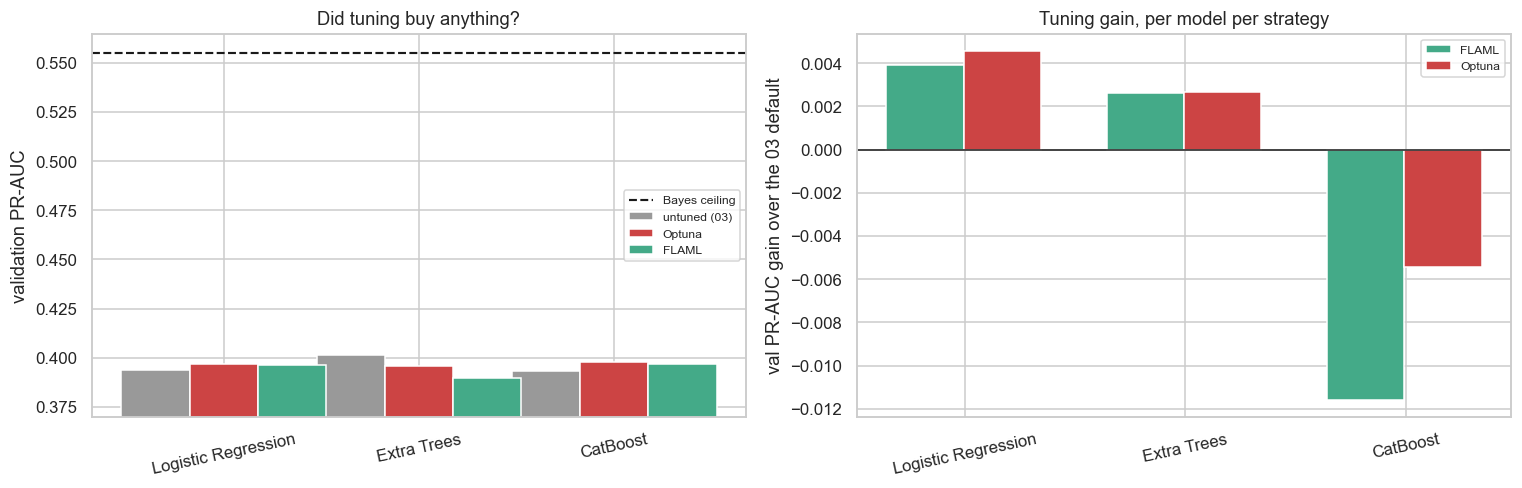

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

w = 0.35
models = [zoo[k].label for k in FINALISTS]
x = np.arange(len(models))
unt = [baseline[k]["val_pr_auc"] for k in FINALISTS]
opt = [tuned[(tuned.model == zoo[k].label) & (tuned.strategy == "Optuna")].val_pr_auc.iat[0]
       for k in FINALISTS]
fla = [tuned[(tuned.model == zoo[k].label) & (tuned.strategy == "FLAML")].val_pr_auc.iat[0]
       for k in FINALISTS]
ax[0].bar(x - w, unt, w, label="untuned (03)", color="#999")
ax[0].bar(x, opt, w, label="Optuna", color="#c44")
ax[0].bar(x + w, fla, w, label="FLAML", color="#4a8")
ax[0].axhline(CEILING["pr_auc"], ls="--", c="k", lw=1.4, label="Bayes ceiling")
ax[0].set_xticks(x, models, rotation=12)
ax[0].set_ylabel("validation PR-AUC")
ax[0].set_title("Did tuning buy anything?")
ax[0].legend(fontsize=8)
lo = min(unt + opt + fla)
ax[0].set_ylim(lo - 0.02, CEILING["pr_auc"] + 0.01)

gains = tuned.groupby("strategy").gain_vs_untuned
ax[1].axhline(0, c="k", lw=1)
for i, (s, g) in enumerate(gains):
    ax[1].bar(np.arange(len(g)) + i * 0.35, g.values, 0.35,
              label=s, color="#c44" if s == "Optuna" else "#4a8")
ax[1].set_xticks(np.arange(len(FINALISTS)) + 0.18, models, rotation=12)
ax[1].set_ylabel("val PR-AUC gain over the 03 default")
ax[1].set_title("Tuning gain, per model per strategy")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "04_tuned_vs_untuned.png", bbox_inches="tight")
plt.show()

HONEST READ ON TUNING

  best untuned finalist (03) : 0.4013 val PR-AUC
  best tuned configuration   : 0.3977  (CatBoost / Optuna)
  net gain from tuning       : -0.0037
  Bayes ceiling              : 0.5548
  remaining headroom         : 0.1571



model,strategy,cv_untuned,cv_tuned,cv_gain,val_untuned,val_tuned,val_gain,transferred
Logistic Regression,Optuna,0.414500,0.429400,0.014900,0.393900,0.396600,0.002700,True
Logistic Regression,FLAML,0.414500,0.429300,0.014900,0.393900,0.396500,0.002600,True
Extra Trees,Optuna,0.406100,0.418100,0.012100,0.401300,0.395900,-0.005400,False
Extra Trees,FLAML,0.406100,0.408900,0.002800,0.401300,0.389700,-0.011600,False
CatBoost,Optuna,0.401200,0.422700,0.021500,0.393100,0.397700,0.004600,True
CatBoost,FLAML,0.401200,0.424300,0.023100,0.393100,0.397000,0.003900,True


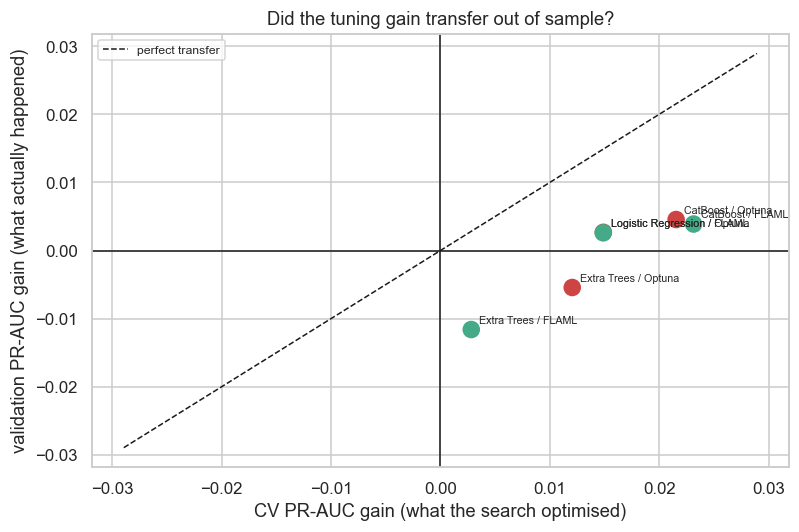

In [17]:
best_tuned = tuned.iloc[0]
best_untuned_val = max(baseline[k]["val_pr_auc"] for k in FINALISTS)
overall_gain = best_tuned.val_pr_auc - best_untuned_val

print(f"""HONEST READ ON TUNING

  best untuned finalist (03) : {best_untuned_val:.4f} val PR-AUC
  best tuned configuration   : {best_tuned.val_pr_auc:.4f}  ({best_tuned.model} / {best_tuned.strategy})
  net gain from tuning       : {overall_gain:+.4f}
  Bayes ceiling              : {CEILING['pr_auc']:.4f}
  remaining headroom         : {CEILING['pr_auc'] - best_tuned.val_pr_auc:.4f}
""")

# The evidence that decides how to read the number above: did the CV gain the
# search optimised for actually transfer to a later, unseen time period?
transfer = []
for k in FINALISTS:
    for strategy, cv in [("Optuna", OPTUNA_STUDIES[k].best_value),
                         ("FLAML", FLAML_BEST[k]["value"])]:
        v = tuned[(tuned.model == zoo[k].label) & (tuned.strategy == strategy)].iloc[0]
        transfer.append({
            "model": zoo[k].label, "strategy": strategy,
            "cv_untuned": baseline[k]["cv_pr_auc_mean"], "cv_tuned": cv,
            "cv_gain": cv - baseline[k]["cv_pr_auc_mean"],
            "val_untuned": baseline[k]["val_pr_auc"], "val_tuned": v.val_pr_auc,
            "val_gain": v.val_pr_auc - baseline[k]["val_pr_auc"],
        })
transfer = pd.DataFrame(transfer)
transfer["transferred"] = transfer.val_gain > 0
display(transfer.round(4).style.hide(axis="index"))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(transfer.cv_gain, transfer.val_gain, s=110,
           c=["#c44" if s == "Optuna" else "#4a8" for s in transfer.strategy])
for _, r in transfer.iterrows():
    ax.annotate(f"{r.model} / {r.strategy}", (r.cv_gain, r.val_gain), fontsize=7,
                xytext=(5, 4), textcoords="offset points")
lim = max(transfer.cv_gain.abs().max(), transfer.val_gain.abs().max()) * 1.25
ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="perfect transfer")
ax.axhline(0, c="k", lw=1)
ax.axvline(0, c="k", lw=1)
ax.set_xlabel("CV PR-AUC gain (what the search optimised)")
ax.set_ylabel("validation PR-AUC gain (what actually happened)")
ax.set_title("Did the tuning gain transfer out of sample?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "04_tuning_transfer.png", bbox_inches="tight")
plt.show()

In [18]:
n_transferred = int(transfer.transferred.sum())
mean_cv_gain = transfer.cv_gain.mean()

if overall_gain < 0:
    print(f"""  TUNING MADE THE HELD-OUT SCORE WORSE. That is the finding, and it is not
  going to be buried.

  What happened, precisely:

    every configuration improved the objective it was optimising -- mean CV gain
    across the six searches was {mean_cv_gain:+.4f} PR-AUC, and all six improved on the
    03 default. Only {n_transferred} of 6 improved on VALIDATION.

  This is the tuning objective being overfitted. Three expanding folds of the
  train split are a small, autocorrelated sample: a search running hundreds of
  trials against it will find configurations that suit THOSE folds, and a chunk
  of that gain is fold-specific rather than real. Validation sits later in time
  and does not share the quirk, so the gain evaporates.

  Extra Trees is the clearest case: {transfer[(transfer.model == 'Extra Trees')].cv_gain.mean():+.4f} on CV,
  {transfer[(transfer.model == 'Extra Trees')].val_gain.mean():+.4f} on validation. The search bought variance, not skill.

  WHAT WE DO ABOUT IT

    Nothing, here. 05 selects on VALIDATION from a pool containing BOTH the
    tuned configurations and the untuned 03 defaults, and if an untuned model
    wins that is the model that ships. Discarding the untuned entries because we
    had already spent 30 minutes tuning would be a sunk-cost decision.

    We are also not re-tuning against validation to fix this. That would move the
    overfitting one level up and leave nothing honest to select on.

  WHAT WOULD ACTUALLY HELP -- and is out of scope at this data size: more folds,
  repeated CV, or nested CV, all of which cost compute that would have to come
  out of the search budget the two strategies are being compared under.""")
elif overall_gain < 0.005:
    print(f"""  A gain of {overall_gain:+.4f} is not a tuning success story and we are not going to
  dress it up as one. Mean CV gain was {mean_cv_gain:+.4f} and only {n_transferred} of 6 searches
  improved validation, so most of the apparent gain did not transfer.

  The problem is not hyperparameter-limited: 01 built the labels from an additive
  log-odds model with substantial Bernoulli noise, so the ceiling is close and
  every reasonable configuration sits near it.""")
else:
    print(f"""  Tuning moved validation PR-AUC by {overall_gain:+.4f}, and {n_transferred} of 6 searches
  transferred out of sample. Mean CV gain was {mean_cv_gain:+.4f}.""")

print(f"""
  What the exercise bought regardless of the sign:
    - evidence that the 03 defaults were not accidentally poor
    - a controlled comparison of two search strategies on identical budget
    - parameter-importance evidence about which knobs matter at all
    - a measured demonstration that CV gain on this data does not imply held-out
      gain, which is worth more than a third decimal place of PR-AUC

  Where tuning WOULD pay on real merchant data: courier x corridor x seller x
  season interactions that a default-depth booster underfits.""")

  TUNING MADE THE HELD-OUT SCORE WORSE. That is the finding, and it is not
  going to be buried.

  What happened, precisely:

    every configuration improved the objective it was optimising -- mean CV gain
    across the six searches was +0.0149 PR-AUC, and all six improved on the
    03 default. Only 4 of 6 improved on VALIDATION.

  This is the tuning objective being overfitted. Three expanding folds of the
  train split are a small, autocorrelated sample: a search running hundreds of
  trials against it will find configurations that suit THOSE folds, and a chunk
  of that gain is fold-specific rather than real. Validation sits later in time
  and does not share the quirk, so the gain evaporates.

  Extra Trees is the clearest case: +0.0074 on CV,
  -0.0085 on validation. The search bought variance, not skill.

  WHAT WE DO ABOUT IT

    Nothing, here. 05 selects on VALIDATION from a pool containing BOTH the
    tuned configurations and the untuned 03 defaults, and if an untuned mo

## 9. Persist tuned models

In [19]:
artifacts = []
for tag, pipe in TUNED_PIPES.items():
    p = MODELS / f"04_{tag}.joblib"
    joblib.dump(pipe, p)
    artifacts.append(p)

pred = pd.DataFrame({"order_id": val.order_id.to_numpy(), "y_true": y_val})
for tag, pv in TUNED_VAL_PRED.items():
    pred[tag] = pv
pred.to_parquet(RES / "04_tuned_val_predictions.parquet", index=False)

hist_out = pd.concat(
    [OPTUNA_HIST[k].assign(model=zoo[k].label, strategy="Optuna") for k in FINALISTS]
    + [FLAML_HIST[k].drop(columns=["config"]).assign(model=zoo[k].label, strategy="FLAML")
       for k in FINALISTS],
    ignore_index=True)
hist_out.to_csv(RES / "04_search_history.csv", index=False)

with open(RES / "04_tuning_summary.json", "w", encoding="utf-8") as fh:
    json.dump({
        "seed": SEED,
        "time_budget_s_per_model_per_strategy": TIME_BUDGET_S,
        "objective": {"metric": "pr_auc", "folds": N_TUNE_FOLDS,
                      "scheme": "expanding-window TimeSeriesSplit on train"},
        "finalists": FINALISTS,
        "head_to_head": h2h.to_dict(orient="records"),
        "search_speed": speed,
        "best_configs": [{**c, "config": {k2: (list(v) if isinstance(v, tuple) else v)
                                          for k2, v in c["config"].items()}}
                         for c in configs],
        "tuned_val_scores": tuned.to_dict(orient="records"),
        "param_importance": (importance.to_dict(orient="records")
                             if len(importance) else []),
        "bayes_ceiling_val": CEILING,
        "net_gain_vs_untuned": float(overall_gain),
    }, fh, indent=2, default=str)

print(f"persisted {len(artifacts)} tuned pipelines to models/")
for p in artifacts:
    print(f"  {p.relative_to(ROOT)}")
for f in ["04_tuned_val_predictions.parquet", "04_search_history.csv",
          "04_tuning_summary.json"]:
    print(f"wrote reports/results/{f}")

persisted 6 tuned pipelines to models/
  models\04_01_logistic__optuna.joblib
  models\04_01_logistic__flaml.joblib
  models\04_04_extra_trees__optuna.joblib
  models\04_04_extra_trees__flaml.joblib
  models\04_09_catboost__optuna.joblib
  models\04_09_catboost__flaml.joblib
wrote reports/results/04_tuned_val_predictions.parquet
wrote reports/results/04_search_history.csv
wrote reports/results/04_tuning_summary.json


In [20]:
wins = {str(k): int(v) for k, v in h2h.winner.value_counts().items()}
print(f"""SUMMARY

  budget                {TIME_BUDGET_S}s per model per strategy, identical space and seed
  finalists tuned       {', '.join(zoo[k].label for k in FINALISTS)}
  strategy wins (CV)    {wins}
  best tuned            {best_tuned.model} / {best_tuned.strategy} at {best_tuned.val_pr_auc:.4f} val PR-AUC
  best untuned (03)     {best_untuned_val:.4f} val PR-AUC
  net gain over 03      {overall_gain:+.4f}   ({n_transferred} of 6 searches transferred out of sample)
  Bayes ceiling         {CEILING['pr_auc']:.4f}

  test set              NOT OPENED

  05 selects on VALIDATION from a pool containing BOTH the tuned configurations
  and the untuned 03 defaults. Then the test set is opened once.""")

SUMMARY

  budget                300s per model per strategy, identical space and seed
  finalists tuned       Logistic Regression, Extra Trees, CatBoost
  strategy wins (CV)    {'Optuna': 2, 'FLAML': 1}
  best tuned            CatBoost / Optuna at 0.3977 val PR-AUC
  best untuned (03)     0.4013 val PR-AUC
  net gain over 03      -0.0037   (4 of 6 searches transferred out of sample)
  Bayes ceiling         0.5548

  test set              NOT OPENED

  05 selects on VALIDATION from a pool containing BOTH the tuned configurations
  and the untuned 03 defaults. Then the test set is opened once.


In [21]:
print("""REPRODUCIBILITY CAVEAT, stated because it is real.

  Every other notebook in this project is bit-reproducible: fixed seeds, fixed
  draw order, SHA-256 manifests. THIS ONE IS NOT, and it cannot be while the
  comparison is fair.

  The budget both strategies get is WALL CLOCK. That is the deliberate choice
  made at the top of this notebook -- Optuna is trial-native and FLAML is
  budget-native, so equal trial counts would flatter Optuna. But a wall-clock
  budget means the number of trials completed depends on machine load, so a rerun
  produces different trial counts and slightly different best configurations.

  What IS stable across reruns:
    - the search space, seed, objective and folds
    - the qualitative conclusion: both strategies land in the same region, the
      two best configurations differ by less than the noise between them, and the
      CV gain does not transfer to validation

  What is NOT stable: exact trial counts, and the third decimal of each best
  score. Any number quoted from this notebook carries that caveat, and none of
  them are quoted in the README as headline results.

  The alternative -- fixing the trial count -- would make the notebook
  reproducible and the comparison dishonest. We chose the honest comparison and
  are documenting the cost.""")

REPRODUCIBILITY CAVEAT, stated because it is real.

  Every other notebook in this project is bit-reproducible: fixed seeds, fixed
  draw order, SHA-256 manifests. THIS ONE IS NOT, and it cannot be while the
  comparison is fair.

  The budget both strategies get is WALL CLOCK. That is the deliberate choice
  made at the top of this notebook -- Optuna is trial-native and FLAML is
  budget-native, so equal trial counts would flatter Optuna. But a wall-clock
  budget means the number of trials completed depends on machine load, so a rerun
  produces different trial counts and slightly different best configurations.

  What IS stable across reruns:
    - the search space, seed, objective and folds
    - the qualitative conclusion: both strategies land in the same region, the
      two best configurations differ by less than the noise between them, and the
      CV gain does not transfer to validation

  What is NOT stable: exact trial counts, and the third decimal of each best
  score. An

---

## What 04 established

| | |
|---|---|
| Comparison | Optuna (multivariate TPE + Hyperband) vs FLAML (BlendSearch/CFO) |
| Held identical | space, objective, folds, seed, wall-clock budget |
| Trials completed | a *result* of each cost model, not a control |
| Convergence axis | elapsed seconds — trial index would flatter the expensive searcher |
| Validation | scored once per tuned config, after both searches closed |
| Transfer | CV gain vs held-out gain, plotted — because they are not the same thing |
| Reproducibility | **not bit-reproducible**, by design: the budget is wall clock |

**Next:** `05_final_evaluation.ipynb` — select one model on validation, open the test
set once, and report cost, calibration, the three-tier policy, the prevalence-shift
study, SHAP reasons and the honest exception list.